# Workforce Analysis of Garden Service Providers

## 1. Introduction

This report builds on the **Comparative Analysis of Garden Service Providers** (93 listings across 20 services, 25 companies, and 3 locations in the Kathmandu Valley) to assess the workforce landscape for each garden and landscaping service.

For each of the 20 services, this analysis brings together:
- **Provider Found** - the number of listed providers offering that service (from the comparative dataset)
- **Demand Level** - an informed estimate of market demand (High / Medium / Low)
- **Competition Level** - how crowded the service is, derived from the number of providers relative to the market average
- **Rank** - the service's position by provider count (1 = most providers)
- **% Formal Companies / % App or Platform / % Directory or Informal** - the provider-type mix within each service
- **Supply Status** - whether a service is Well-served, Sufficient, or Limited, based on provider count relative to the average

The goal is to identify which services are saturated, which are underserved relative to demand, and where the market's real opportunities and gaps sit.

## 2. Setup

In [1]:
# Importing the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading the dataset
df = pd.read_excel("Workforce_Analysis.xlsx")

print(df.columns.tolist(), "\n")
print(df.head())

['ID', 'Service', 'Provider Found', 'Demand', 'Competition Level', 'Rank', '% Formal Companies', '% App or Platform', '% Directory or Informal', 'Supply Status'] 

   ID                     Service  Provider Found  Demand Competition Level  \
0   1                   Lawn Care               9    High              High   
1   2  Planting and Transplanting               7  Medium              High   
2   3          Garden Maintenance              10    High              High   
3   4            Soil Improvement               1     Low               Low   
4   5         Irrigation Services               2  Medium               Low   

   Rank  % Formal Companies  % App or Platform  % Directory or Informal  \
0     4            0.777778           0.111111                 0.111111   
1     5            0.857143           0.142857                 0.000000   
2     2            0.900000           0.100000                 0.000000   
3    17            1.000000           0.000000               

## 3. Data Overview

In [3]:
# Structural Summary
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       20 non-null     int64  
 1   Service                  20 non-null     object 
 2   Provider Found           20 non-null     int64  
 3   Demand                   20 non-null     object 
 4   Competition Level        20 non-null     object 
 5   Rank                     20 non-null     int64  
 6   % Formal Companies       20 non-null     float64
 7   % App or Platform        20 non-null     float64
 8   % Directory or Informal  20 non-null     float64
 9   Supply Status            20 non-null     object 
dtypes: float64(3), int64(3), object(4)
memory usage: 1.7+ KB
None


In [4]:
# Statistical Summary
print(df.describe())

             ID  Provider Found       Rank  % Formal Companies  \
count  20.00000        20.00000  20.000000           20.000000   
mean   10.50000         4.65000   9.550000            0.914802   
std     5.91608         4.33195   5.206019            0.117025   
min     1.00000         1.00000   1.000000            0.666667   
25%     5.75000         2.00000   5.750000            0.851190   
50%    10.50000         3.00000  10.000000            1.000000   
75%    15.25000         6.25000  12.000000            1.000000   
max    20.00000        18.00000  17.000000            1.000000   

       % App or Platform  % Directory or Informal  
count          20.000000                20.000000  
mean            0.028810                 0.056389  
std             0.054781                 0.113201  
min             0.000000                 0.000000  
25%             0.000000                 0.000000  
50%             0.000000                 0.000000  
75%             0.013889                 

In [5]:
# Quick check on distribution across key categorical columns
print(f"Total services: {len(df)}\n")
print(df["Supply Status"].value_counts(), "\n")
print(df["Demand"].value_counts(), "\n")
print(df["Competition Level"].value_counts(), "\n")

Total services: 20

Supply Status
Limited        11
Well-served     5
Sufficient      4
Name: count, dtype: int64 

Demand
Medium    9
Low       8
High      3
Name: count, dtype: int64 

Competition Level
Low       11
High       5
Medium     4
Name: count, dtype: int64 



**Insight:** The dataset covers all **20 services** from the comparative analysis. Provider Found ranges from just **1** (Soil Improvement, Plant Propagation, Rooftop Gardening, Artificial Gardening) to **18** (Pest and Disease Control), an 18x spread, with most services sitting well below the average of 4.65. Supply Status skews toward scarcity: **11 of 20 services are "Limited,"** compared to only **5 "Well-served"** and **4 "Sufficient."** Competition Level follows nearly the same split, **Low (11)**, **High (5)**, **Medium (4)**, which lines up with Supply Status since both come from provider count. Demand is spread mostly across **Medium (9 services)** and **Low (8 services)**, with only **3 services rated High demand.**

## 4. Visual Analysis
### Chart 1 - Number of Providers Found per Service

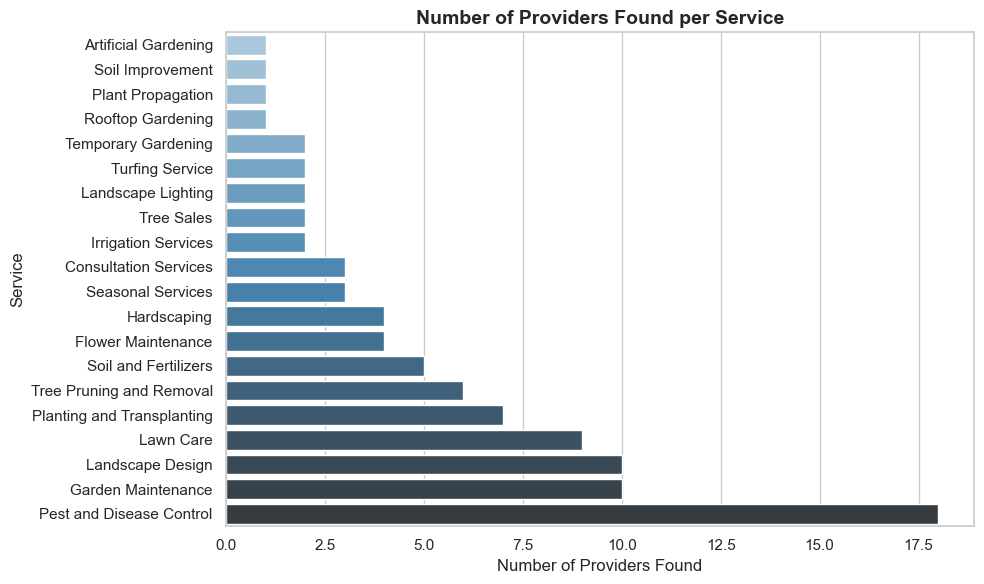

In [6]:
sns.set_theme(style="whitegrid")
df_sorted = df.sort_values("Provider Found", ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_sorted, x="Provider Found", y="Service", hue="Service", palette="Blues_d", legend=False)

plt.title("Number of Providers Found per Service", fontsize=14, fontweight="bold")
plt.xlabel("Number of Providers Found", fontsize=12)
plt.ylabel("Service", fontsize=12)
plt.tight_layout()
plt.savefig("chart1.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight:** Pest and Disease Control has way more providers than anything else, sitting far above the rest of the chart. Garden Maintenance and Landscape Design come next, both with a good number of providers, then Lawn Care and Planting and Transplanting after that. On the other end, Soil Improvement, Plant Propagation, Rooftop Gardening, and Artificial Gardening all sit at the bottom with barely any providers. So the market isn't spread out evenly, a few services get most of the attention while several others are barely served.

### Chart 2 - Formal vs App vs Directory Share Across All Services

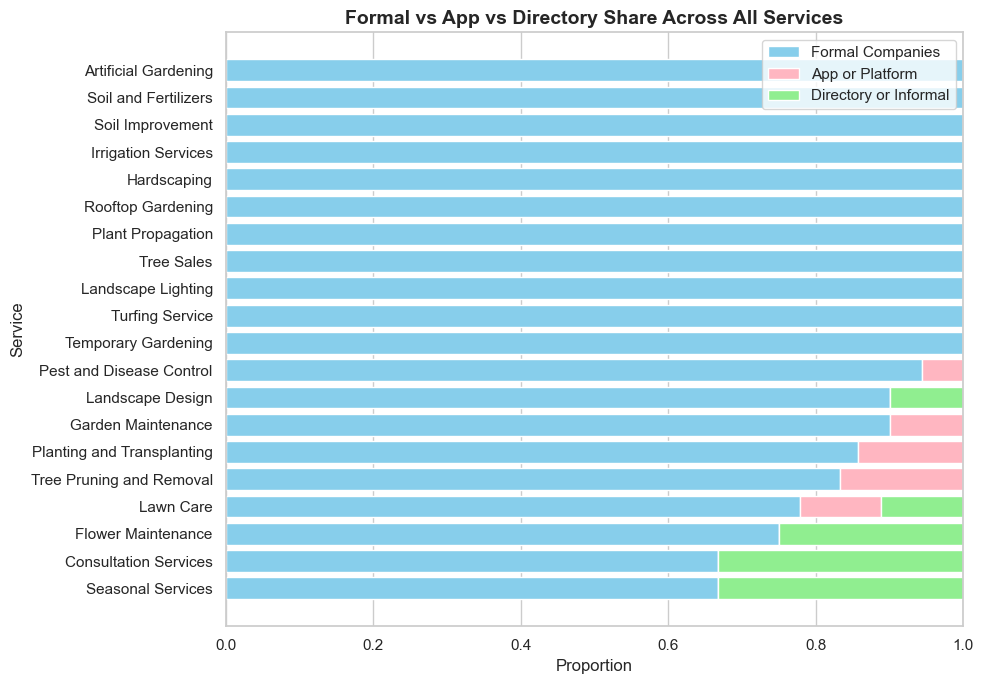

In [7]:
sns.set_theme(style="whitegrid")
df_sorted = df.sort_values("% Formal Companies", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(df_sorted["Service"], df_sorted["% Formal Companies"], label="Formal Companies", color="skyblue")
plt.barh(df_sorted["Service"], df_sorted["% App or Platform"], 
         left=df_sorted["% Formal Companies"], label="App or Platform", color="lightpink")
plt.barh(df_sorted["Service"], df_sorted["% Directory or Informal"], 
         left=df_sorted["% Formal Companies"] + df_sorted["% App or Platform"], label="Directory or Informal", color="lightgreen")

plt.title("Formal vs App vs Directory Share Across All Services", fontsize=14, fontweight="bold")
plt.xlabel("Proportion", fontsize=12)
plt.ylabel("Service", fontsize=12)
plt.legend(loc="upper right")

plt.tight_layout()
plt.savefig("chart2.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight:** Formal companies dominate this market. Services like Soil Improvement, Irrigation Services, Hardscaping, Tree Sales, and Turfing Service are handled only by formal companies, with no app or informal providers at all. A few services do have some app-based providers mixed in, like Pest and Disease Control, Garden Maintenance, and Tree Pruning and Removal, but formal companies still make up most of the bar. Services like Landscape Design, Flower Maintenance, and Consultation Services have some informal or directory-based providers instead. Lawn Care is the only service that has all three types together. Either way, formal companies are present in every single service, so nothing runs without them.

### Chart 3 - Demand Level Distribution

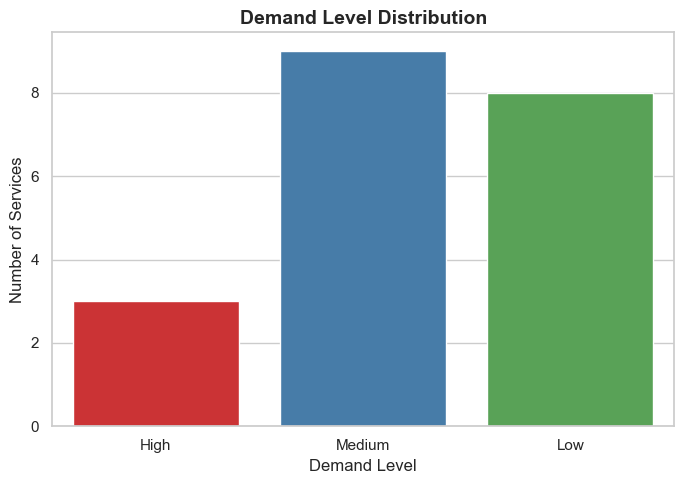

In [8]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(7,5))
sns.countplot(data=df, x="Demand", hue="Demand", palette="Set1", legend=False, order=["High", "Medium", "Low"])

plt.title("Demand Level Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Demand Level", fontsize=12)
plt.ylabel("Number of Services", fontsize=12)
plt.tight_layout()
plt.savefig("chart3.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight:** Only 3 of 20 services (Lawn Care, Garden Maintenance, Pest and Disease Control) are rated High demand, reflecting the recurring and essential nature of these upkeep services. The bulk of the catalog (9 services) sits at Medium demand, and 8 services are Low demand, generally the more niche or project-based offerings like Landscape Lighting, Artificial Gardening, and Plant Propagation.

### Chart 4 - Supply Status Distribution

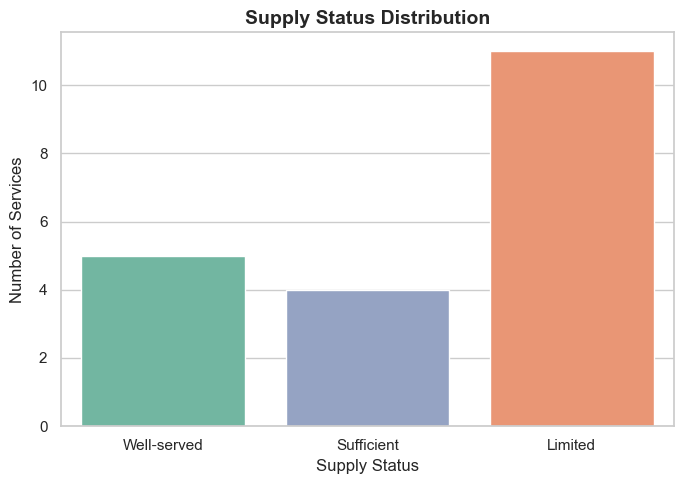

In [9]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(7,5))
sns.countplot(data=df, x="Supply Status", hue="Supply Status", palette="Set2", legend=False, 
              order=["Well-served", "Sufficient", "Limited"])

plt.title("Supply Status Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Supply Status", fontsize=12)
plt.ylabel("Number of Services", fontsize=12)
plt.tight_layout()
plt.savefig("chart4.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight:** More than half the catalog, 11 of 20 services, falls into "Limited" supply. Just 5 services are "Well-served" and 4 are "Sufficient." Combined with the demand distribution above, this points to a market where provider availability lags behind the number of distinct services people might want.

### Chart 5 - Competition Level Distribution

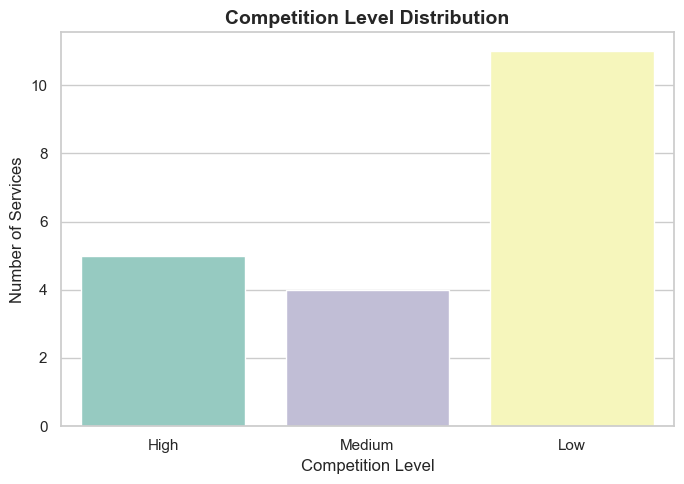

In [10]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(7,5))
sns.countplot(data=df, x="Competition Level", hue="Competition Level", palette="Set3", legend=False, 
              order=["High", "Medium", "Low"])

plt.title("Competition Level Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Competition Level", fontsize=12)
plt.ylabel("Number of Services", fontsize=12)
plt.tight_layout()
plt.savefig("chart5.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight:** Most services, including Soil Improvement, Tree Sales, and Temporary Gardening, have Low competition. Fewer services, like Pest and Disease Control, Garden Maintenance, and Lawn Care, face High competition, and only a small group like Hardscaping and Flower Maintenance sit at Medium. So for most services, there isn't much competition between providers.

### Chart 6 - Demand Level vs Competition Level

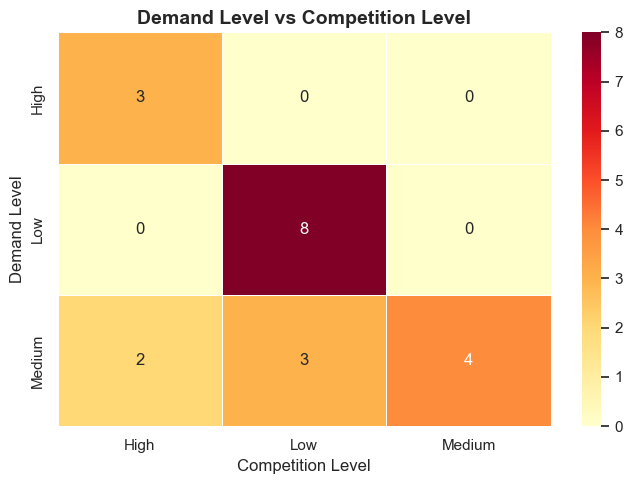

In [11]:
sns.set_theme(style="whitegrid")
cross_tab = pd.crosstab(df["Demand"], df["Competition Level"])

plt.figure(figsize=(7,5))
sns.heatmap(cross_tab, annot=True, fmt="d", cmap="YlOrRd", linewidth=0.5)

plt.title("Demand Level vs Competition Level", fontsize=14, fontweight="bold")
plt.xlabel("Competition Level", fontsize=12)
plt.ylabel("Demand Level", fontsize=12)
plt.tight_layout()
plt.savefig("chart6.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight:** Services with High demand, like Lawn Care, Garden Maintenance, and Pest and Disease Control, all also have High competition, none of them have Low or Medium competition. On the other side, all the Low demand services also have Low competition. Medium demand services are the only ones that spread across all three competition levels, so they don't follow one clear pattern like the High and Low demand services do.

### Chart 7 - Providers Found vs Rank

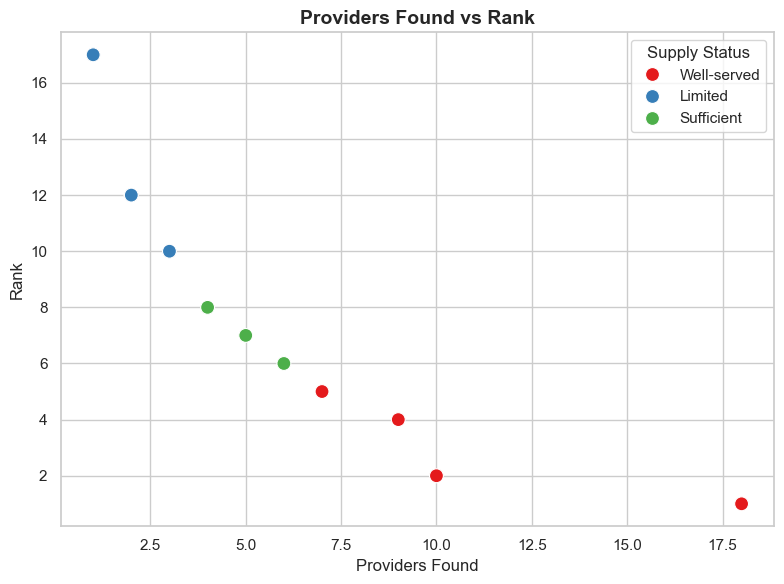

In [12]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="Provider Found", y="Rank", hue="Supply Status", palette="Set1", s=100)

plt.title("Providers Found vs Rank", fontsize=14, fontweight="bold")
plt.xlabel("Providers Found", fontsize=12)
plt.ylabel("Rank", fontsize=12)
plt.legend(title="Supply Status")
plt.tight_layout()
plt.savefig("chart7.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight:** As expected, Rank falls sharply as Provider Found rises, and the color coding confirms the Well-served / Sufficient / Limited bands sit in distinct clusters along that curve. The four services tied at Rank 17 (only 1 provider each) sit furthest to the left and are all "Limited," visually confirming them as the most under-supplied points in the dataset.

## 5. Key Findings

1. **Supply lags behind the service catalog:** 11 of 20 services are "Limited" in supply, versus only 5 "Well-served." Most of the market's 93 providers are concentrated in a handful of services, leaving the majority of the catalog thinly served.

2. **Demand and supply are mismatched at the extremes:** Pest and Disease Control is both High demand and Well-served (18 providers), making it a mature, saturated market. In contrast, Irrigation Services, Seasonal Services, and Rooftop Gardening carry Medium demand but Low competition and Limited supply, marking them as the clearest under-served opportunities in the dataset.

3. **Competition Level is mechanically tied to Supply Status:** because both are derived from the same Provider Found thresholds, they produce identical group sizes (5 High/Well-served, 4 Medium/Sufficient, 11 Low/Limited). In this dataset, provider count alone is driving both signals.

4. **Formal companies dominate the workforce:** 11 of 20 services are served exclusively by organized companies, with no app-based or informal presence at all. App/marketplace platforms only have a foothold in 5 services: Tree Pruning and Removal, Planting and Transplanting, Lawn Care, Garden Maintenance, and Pest and Disease Control. In all of these, the app segment is only a small slice of the bar, formal companies still make up most of it.

5. **The most saturated services cluster together:** Pest and Disease Control, Garden Maintenance, Landscape Design, Lawn Care, and Planting and Transplanting account for over half of all 93 listed providers between them, while the remaining 15 services split the rest.

6. **Four services are essentially single-provider markets:** Soil Improvement, Plant Propagation, Rooftop Gardening, and Artificial Gardening each have exactly 1 provider, indicating either a genuinely niche service or a real opening for a second entrant.

### Overall Takeaway
The garden services workforce in the Kathmandu Valley is concentrated around a small set of high-demand, high-competition services, led by Pest and Disease Control, Garden Maintenance, and Lawn Care, that are already well supplied by formal companies. Most of the remaining catalog is thinly served, and a few Medium-demand, Low-competition services, including Irrigation, Seasonal Services, and Rooftop Gardening, stand out as the most promising gaps for new or expanding providers.